In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# ============================================================
# CREDIT CARD FRAUD DETECTION
# Methods: Logistic Regression | Random Forest
# Dataset: ULB Credit Card Fraud Detection
# ============================================================

# ============================================================
# Libraries
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    average_precision_score,
    precision_score,
    recall_score,
    f1_score
)

import time

In [6]:
# ============================================================
# Load & Verify Dataset
# ============================================================

# COLAB PATH:
df = pd.read_csv('creditcard.csv')



for i in range(1, 29):
    col_name = f'V{i}'
    if col_name in df.columns:
        df[col_name] = pd.to_numeric(df[col_name], errors='coerce')

# Dataset
print(f"Dataset shape: {df.shape}")
print(f"Transactions: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
print(f"Fraud cases: {df['Class'].sum()}")
print(f"Fraud rate: {df['Class'].mean()*100:.4f}%")
print(f"Missing values: {df.isnull().sum().sum()}")

Dataset shape: (284807, 31)
Transactions: 284807
Columns: 31
Fraud cases: 492
Fraud rate: 0.1727%
Missing values: 0


In [7]:
# ============================================================
# Feature Extraction & Scaling
# ============================================================

X = df.drop('Class', axis=1)
y = df['Class']

X = X.values
y = y.values

scaler = RobustScaler()
X = scaler.fit_transform(X)

In [11]:
# ============================================================
# Models
# ============================================================

rf_model = RandomForestClassifier(
    n_estimators=10,
    random_state=42,
    n_jobs=-1
)

lr_model = LogisticRegression(max_iter=1000)

In [12]:
# ============================================================
# Risk 1: Cross-Validation (AUPRC Variance)
# ============================================================

def cv_auprc(model, X, y, n_splits=5):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    scores = []

    for train_idx, val_idx in skf.split(X, y):
        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]

        model.fit(X_train, y_train)
        probs = model.predict_proba(X_val)[:, 1]

        score = average_precision_score(y_val, probs)
        scores.append(score)

    return np.mean(scores), np.std(scores)

start = time.time()

rf_mean, rf_std = cv_auprc(rf_model, X, y)
lr_mean, lr_std = cv_auprc(lr_model, X, y)

end = time.time()

print("\n--- Cross Validation Results ---")
print(f"RF AUPRC: {rf_mean:.4f} ± {rf_std:.4f}")
print(f"LR AUPRC: {lr_mean:.4f} ± {lr_std:.4f}")
print(f"Runtime: {end - start:.2f} seconds")


--- Cross Validation Results ---
RF AUPRC: 0.8375 ± 0.0210
LR AUPRC: 0.7599 ± 0.0205
Runtime: 474.52 seconds


In [14]:
# ============================================================
# Collect Predictions for Analysis
# ============================================================

def get_predictions(model, X, y):
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    all_probs = []
    all_true = []

    for train_idx, val_idx in skf.split(X, y):
        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]

        model.fit(X_train, y_train)
        probs = model.predict_proba(X_val)[:, 1]

        all_probs.extend(probs)
        all_true.extend(y_val)

    return np.array(all_true), np.array(all_probs)

rf_true, rf_probs = get_predictions(rf_model, X, y)

print(rf_true[:10])
print(rf_probs[:10])

[0 0 0 0 0 0 0 0 0 0]
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [15]:
# ============================================================
# Risk 1 (continued): Bootstrap Confidence Intervals
# ============================================================

def bootstrap_ci(y_true, y_probs, n_bootstrap=1000):
    scores = []
    n = len(y_true)

    for _ in range(n_bootstrap):
        idx = np.random.choice(n, n, replace=True)

        if len(np.unique(y_true[idx])) < 2:
            continue

        score = average_precision_score(y_true[idx], y_probs[idx])
        scores.append(score)

    mean = np.mean(scores)
    lower = np.percentile(scores, 2.5)
    upper = np.percentile(scores, 97.5)

    return mean, lower, upper

mean, low, high = bootstrap_ci(rf_true, rf_probs)

print("\n--- Bootstrap CI ---")
print(f"RF AUPRC: {mean:.4f} (95% CI: [{low:.4f}, {high:.4f}])")


--- Bootstrap CI ---
RF AUPRC: 0.8363 (95% CI: [0.8055, 0.8674])


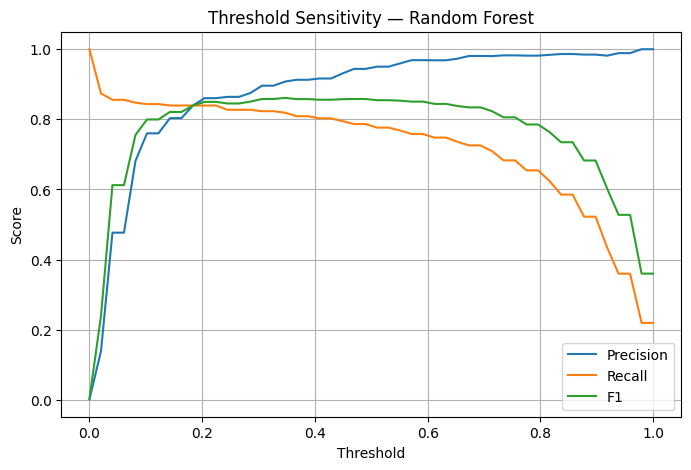

In [16]:
# ============================================================
# Risk 2: Threshold Sweep
# ============================================================

thresholds = np.linspace(0, 1, 50)

precision_list, recall_list, f1_list = [], [], []

for t in thresholds:
    preds = (rf_probs >= t).astype(int)

    precision_list.append(precision_score(rf_true, preds))
    recall_list.append(recall_score(rf_true, preds))
    f1_list.append(f1_score(rf_true, preds))

plt.figure(figsize=(8,5))
plt.plot(thresholds, precision_list, label='Precision')
plt.plot(thresholds, recall_list, label='Recall')
plt.plot(thresholds, f1_list, label='F1')
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold Sensitivity — Random Forest")
plt.legend()
plt.grid()
plt.show()

In [17]:
# ============================================================
# Risk 3: Cost-Sensitive Analysis
# ============================================================

def compute_cost(y_true, y_probs, threshold=0.5, cost_fn=122, cost_fp=5):
    preds = (y_probs >= threshold).astype(int)

    total_cost = 0
    for yt, yp in zip(y_true, preds):
        if yt == 1 and yp == 0:
            total_cost += cost_fn
        elif yt == 0 and yp == 1:
            total_cost += cost_fp

    return total_cost / len(y_true)

cost = compute_cost(rf_true, rf_probs)

print("\n--- Cost Analysis ---")
print(f"Cost per transaction: ${cost:.4f}")


--- Cost Analysis ---
Cost per transaction: $0.0454
